## Modelo de regresion con ingenieria de variables

En esta seccion se implementa un flujo completo para predecir Consumption:
- Carga y exploracion del CSV original.
- Analisis de variables candidatas desde el dataset fuente.
- Ingenieria temporal + one-hot encoding para hour, day_of_week, month, quarter y year.
- Split tradicional aleatorio train/validation/test (no temporal).
- Entrenamiento y evaluacion con Ridge.
- Visualizacion de predicciones y residuales.

In [1]:
# Librerias base para manipulacion de datos y visualizacion
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modelo lineal y metricas de evaluacion
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Herramientas de preprocesamiento y split tradicional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Ajustes de visualizacion para tablas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [ ]:
# Construimos una ruta reproducible al archivo fuente compartido
from ml_course.data import get_data_path

csv_path = get_data_path("electricity_consumption_and_production.csv", category="external")
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el archivo: {csv_path.resolve()}')

# Cargamos datos originales (consumo + produccion por fuente)
raw = pd.read_csv(csv_path)

# Convertimos DateTime a formato fecha y lo usamos como indice temporal
raw['DateTime'] = pd.to_datetime(raw['DateTime'])
raw = raw.sort_values('DateTime').set_index('DateTime')

# Resumen rapido para entender tamano, columnas y posibles faltantes
print('Shape del dataset original:', raw.shape)
print('Columnas disponibles:', list(raw.columns))
print('Valores nulos por columna:')
print(raw.isna().sum())

# Visualizamos primeras filas del dataset completo
display(raw.head())

Shape del dataset original: (62810, 9)
Columnas disponibles: ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
Valores nulos por columna:
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [3]:
# Analisis de variables candidatas para explicar Consumption
# Evaluamos correlacion lineal de cada variable original contra el target.

candidate_cols = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'Consumption'
]

corr_with_target = raw[candidate_cols].corr(numeric_only=True)['Consumption'] \
    .drop('Consumption') \
    .sort_values(key=np.abs, ascending=False)

print('Correlacion (ordenada por magnitud absoluta) con Consumption:')
display(corr_with_target.to_frame('corr_vs_consumption'))

# Breve conclusion automatica de candidatas
strong_candidates = corr_with_target[np.abs(corr_with_target) >= 0.25].index.tolist()
moderate_candidates = corr_with_target[(np.abs(corr_with_target) >= 0.10) & (np.abs(corr_with_target) < 0.25)].index.tolist()

print('Candidatas fuertes (|corr| >= 0.25):', strong_candidates)
print('Candidatas moderadas (0.10 <= |corr| < 0.25):', moderate_candidates)

Correlacion (ordenada por magnitud absoluta) con Consumption:


,corr_vs_consumption
Production,0.690823
Oil and Gas,0.499442
Coal,0.472298
Biomass,0.400475
Hydroelectric,0.358047
Nuclear,0.161838
Wind,0.102026
Solar,-0.048037


Candidatas fuertes (|corr| >= 0.25): ['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric']
Candidatas moderadas (0.10 <= |corr| < 0.25): ['Nuclear', 'Wind']


In [4]:
# Funcion para generar variables temporales a partir del indice de fechas
def create_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour'] = out.index.hour
    out['day_of_week'] = out.index.day_of_week
    out['month'] = out.index.month
    out['quarter'] = out.index.quarter
    out['year'] = out.index.year
    out['day_of_year'] = out.index.dayofyear
    return out

# Parte 1: ingenieria de variables (aislada, sin split)
feat_df = create_time_features(raw)

# Variables candidatas del dataset de origen (produccion total y por tecnologia)
energy_candidate_features = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass'
]

# Variables categoricas temporales a codificar con one-hot
categorical_time_features = ['hour', 'day_of_week', 'month', 'quarter', 'year']

# One-hot encoding para convertir categorias temporales en variables dummy
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
encoded_array = encoder.fit_transform(feat_df[categorical_time_features])
encoded_cols = encoder.get_feature_names_out(categorical_time_features)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=feat_df.index)

# Variables numericas adicionales (incluye dia del anio como tendencia estacional)
numeric_features = energy_candidate_features + ['day_of_year']

# Dataframe final de modelado con target + variables numericas + dummies temporales
model_df = pd.concat([
    feat_df[['Consumption'] + numeric_features],
    encoded_df
], axis=1)

TARGET = 'Consumption'
FEATURES = [col for col in model_df.columns if col != TARGET]

print('Ingenieria completada.')
print('Total de features para el modelo:', len(FEATURES))
print('Primeras 10 features:', FEATURES[:10])

Ingenieria completada.
Total de features para el modelo: 59
Primeras 10 features: ['Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'day_of_year', 'hour_1']


In [5]:
# Parte 2: split tradicional aleatorio train/validation/test + estandarizacion de variables energeticas
# Separamos primero train (70%) y temporalmente un bloque holdout (30%), luego dividimos holdout en val/test (15%/15%).
train_df, holdout_df = train_test_split(model_df, test_size=0.30, random_state=42, shuffle=True)
val_df, test_df = train_test_split(holdout_df, test_size=0.50, random_state=42, shuffle=True)

# Aseguramos tipo float en las variables a estandarizar para evitar errores de asignacion
cast_map = {col: 'float64' for col in energy_candidate_features}
train_df = train_df.astype(cast_map)
val_df = val_df.astype(cast_map)
test_df = test_df.astype(cast_map)

# Estandarizamos SOLO energy_candidate_features usando estadisticos de train
scaler = StandardScaler()
train_df.loc[:, energy_candidate_features] = scaler.fit_transform(train_df[energy_candidate_features])
val_df.loc[:, energy_candidate_features] = scaler.transform(val_df[energy_candidate_features])
test_df.loc[:, energy_candidate_features] = scaler.transform(test_df[energy_candidate_features])

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val, y_val = val_df[FEATURES], val_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print('Train size:', X_train.shape)
print('Validation size:', X_val.shape)
print('Test size:', X_test.shape)
print('Random state usado: 42')
print('Media train estandarizada (aprox 0):')
print(train_df[energy_candidate_features].mean().round(3).to_dict())
print('Std train estandarizada (aprox 1):')
print(train_df[energy_candidate_features].std().round(3).to_dict())

Train size: (43967, 59)
Validation size: (9421, 59)
Test size: (9422, 59)
Random state usado: 42
Media train estandarizada (aprox 0):
{'Production': 0.0, 'Nuclear': -0.0, 'Wind': -0.0, 'Hydroelectric': -0.0, 'Oil and Gas': -0.0, 'Coal': -0.0, 'Solar': 0.0, 'Biomass': -0.0}
Std train estandarizada (aprox 1):
{'Production': 1.0, 'Nuclear': 1.0, 'Wind': 1.0, 'Hydroelectric': 1.0, 'Oil and Gas': 1.0, 'Coal': 1.0, 'Solar': 1.0, 'Biomass': 1.0}


In [6]:
# Entrenamos un modelo de regresion ridge con todas las features ingenierizadas
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Generamos predicciones sobre validacion y prueba
pred_val = ridge_model.predict(X_val)
pred_ridge = ridge_model.predict(X_test)

# Funcion auxiliar para error porcentual absoluto medio
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Resumen de metricas por split
results = pd.DataFrame([
    {
        'split': 'validation',
        'modelo': 'Ridge',
        'MAE': mean_absolute_error(y_val, pred_val),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val)),
        'R2': r2_score(y_val, pred_val),
        'MAPE_%': mape(y_val, pred_val),
    },
    {
        'split': 'test',
        'modelo': 'Ridge',
        'MAE': mean_absolute_error(y_test, pred_ridge),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_ridge)),
        'R2': r2_score(y_test, pred_ridge),
        'MAPE_%': mape(y_test, pred_ridge),
    }
]).set_index(['split', 'modelo'])

# Analisis de importancia lineal por magnitud de coeficientes
coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coef': ridge_model.coef_,
    'abs_coef': np.abs(ridge_model.coef_)
}).sort_values('abs_coef', ascending=False)

print('Top 12 features por magnitud de coeficiente:')
display(coef_df[['feature', 'coef']].head(12))

results.round(4)

Top 12 features por magnitud de coeficiente:


,feature,coef
21,hour_13,1365.367133
20,hour_12,1353.328789
19,hour_11,1352.319480
18,hour_10,1341.487015
22,hour_14,1257.185316
17,hour_9,1247.521554
28,hour_20,1192.630998
27,hour_19,1187.203031
26,hour_18,1179.378774
25,hour_17,1175.533650


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,Ridge,328.5191,428.3926,0.8373,5.2353
test,Ridge,320.9696,421.1695,0.8443,5.1277


Resumen de error en test:
       error_ridge  abs_error
count     9422.000   9422.000
mean         0.282    320.970
std        421.192    272.709
min      -2357.946      0.131
25%       -252.785    120.852
50%         -0.898    256.297
75%        258.428    455.833
max       3645.284   3645.284


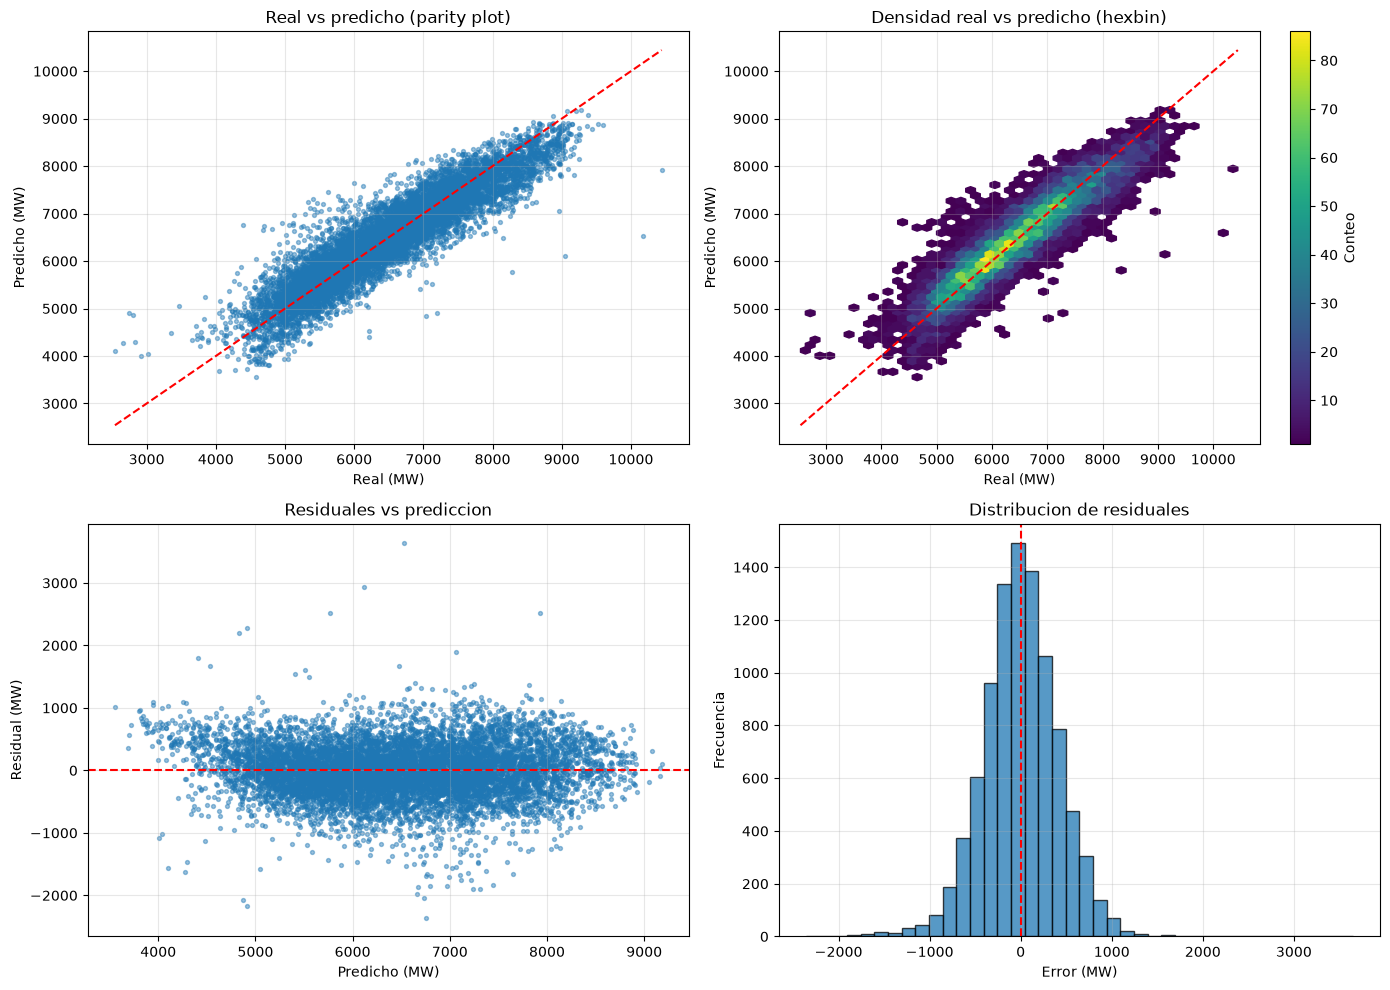

In [7]:
# Analisis de predicciones para split aleatorio (sin orden temporal)
pred_df = pd.DataFrame(index=y_test.index)
pred_df['Consumption'] = y_test
pred_df['pred_ridge'] = pred_ridge
pred_df['error_ridge'] = pred_df['Consumption'] - pred_df['pred_ridge']
pred_df['abs_error'] = pred_df['error_ridge'].abs()

print('Resumen de error en test:')
print(pred_df[['error_ridge', 'abs_error']].describe().round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Parity plot: real vs predicho
axes[0, 0].scatter(pred_df['Consumption'], pred_df['pred_ridge'], s=8, alpha=0.45)
min_v = min(pred_df['Consumption'].min(), pred_df['pred_ridge'].min())
max_v = max(pred_df['Consumption'].max(), pred_df['pred_ridge'].max())
axes[0, 0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 0].set_title('Real vs predicho (parity plot)')
axes[0, 0].set_xlabel('Real (MW)')
axes[0, 0].set_ylabel('Predicho (MW)')
axes[0, 0].grid(alpha=0.3)

# 2) Hexbin para densidad de puntos
hb = axes[0, 1].hexbin(
    pred_df['Consumption'],
    pred_df['pred_ridge'],
    gridsize=45,
    cmap='viridis',
    mincnt=1
)
axes[0, 1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 1].set_title('Densidad real vs predicho (hexbin)')
axes[0, 1].set_xlabel('Real (MW)')
axes[0, 1].set_ylabel('Predicho (MW)')
axes[0, 1].grid(alpha=0.3)
fig.colorbar(hb, ax=axes[0, 1], label='Conteo')

# 3) Residuales vs prediccion
axes[1, 0].scatter(pred_df['pred_ridge'], pred_df['error_ridge'], s=8, alpha=0.45)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Residuales vs prediccion')
axes[1, 0].set_xlabel('Predicho (MW)')
axes[1, 0].set_ylabel('Residual (MW)')
axes[1, 0].grid(alpha=0.3)

# 4) Histograma de residuales
axes[1, 1].hist(pred_df['error_ridge'], bins=40, edgecolor='black', alpha=0.75)
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].set_title('Distribucion de residuales')
axes[1, 1].set_xlabel('Error (MW)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Analisis de coeficientes de la regresion lineal

A partir de los coeficientes estimados (`coef_df`, mostrado en la celda 6), se observan los siguientes patrones:

1. **Predominio de la estacionalidad horaria**
- Las variables dummy de `hour` aparecen entre los coeficientes de mayor magnitud absoluta.
- Esto indica que, manteniendo constantes las demas variables, la hora del dia explica una parte importante del nivel de `Consumption`.
- En terminos practicos, el modelo esta capturando correctamente el ciclo intradiario de demanda.

2. **Interpretacion del signo en variables dummy**
- Un coeficiente positivo en una dummy (por ejemplo, `hour_13`) implica que esa categoria tiende a elevar el consumo respecto a la categoria base omitida por el encoder (`drop='first'`).
- Un coeficiente negativo implicaria lo contrario: menor consumo relativo a la categoria base.

3. **Aporte de variables energeticas de origen**
- Variables como `Production`, `Oil and Gas`, `Coal` o `Hydroelectric` tambien aportan explicacion del consumo.
- Su interpretacion debe hacerse con cuidado porque pueden estar fuertemente correlacionadas entre si y con la propia dinamica temporal.

4. **Cautela: magnitud no siempre equivale a causalidad directa**
- En presencia de multicolinealidad (comun cuando se usan muchas dummies y variables energeticas relacionadas), los coeficientes pueden volverse inestables.
- Por ello, el analisis de coeficientes debe complementarse con metricas de desempeno (MAE, RMSE, R2, MAPE), validacion temporal y, si se requiere inferencia mas robusta, regularizacion (Ridge/Lasso).

5. **Conclusion del modelo actual**
- La regresion lineal esta capturando razonablemente bien la estructura del problema gracias a:
  - dummies temporales (hora/dia/mes/trimestre/anio),
  - `day_of_year` como tendencia estacional,
  - variables energeticas operativas del sistema.
- El resultado es consistente con el salto de desempeno observado frente a la version con features temporales mas simples.

In [8]:
# Busqueda de alpha con RidgeCV y evaluacion en validation/test
from sklearn.linear_model import RidgeCV

alpha_grid = np.logspace(-4, 4, 40)

ridge_cv = RidgeCV(
    alphas=alpha_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
ridge_cv.fit(X_train, y_train)

best_alpha = ridge_cv.alpha_
ridge_tuned = Ridge(alpha=best_alpha)
ridge_tuned.fit(X_train, y_train)

pred_val_tuned = ridge_tuned.predict(X_val)
pred_test_tuned = ridge_tuned.predict(X_test)

def mape_local(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

ridge_cv_results = pd.DataFrame([
    {
        'split': 'validation',
        'modelo': f'RidgeCV (alpha={best_alpha:.6g})',
        'MAE': mean_absolute_error(y_val, pred_val_tuned),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val_tuned)),
        'R2': r2_score(y_val, pred_val_tuned),
        'MAPE_%': mape_local(y_val, pred_val_tuned),
    },
    {
        'split': 'test',
        'modelo': f'RidgeCV (alpha={best_alpha:.6g})',
        'MAE': mean_absolute_error(y_test, pred_test_tuned),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_test_tuned)),
        'R2': r2_score(y_test, pred_test_tuned),
        'MAPE_%': mape_local(y_test, pred_test_tuned),
    }
]).set_index(['split', 'modelo'])

baseline_alpha = ridge_model.alpha if 'ridge_model' in globals() else np.nan
comparison_df = pd.DataFrame([
    {
        'modelo': 'Ridge base',
        'alpha': baseline_alpha,
        'RMSE_val': mean_absolute_error(y_val, ridge_model.predict(X_val)) if 'ridge_model' in globals() else np.nan,
    },
    {
        'modelo': 'RidgeCV seleccionado',
        'alpha': best_alpha,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, pred_val_tuned)),
    }
])

# Corregimos nombre de columna: RMSE_val del baseline
if 'ridge_model' in globals():
    comparison_df.loc[comparison_df['modelo'] == 'Ridge base', 'RMSE_val'] = np.sqrt(mean_squared_error(y_val, ridge_model.predict(X_val)))

print('Alpha seleccionado por RidgeCV:', best_alpha)
print('\nResumen de metricas del modelo ajustado con alpha seleccionado:')
display(ridge_cv_results.round(4))

print('\nComparacion rapida de alpha y RMSE en validation:')
display(comparison_df.round(6))

Alpha seleccionado por RidgeCV: 0.19144819761699575

Resumen de metricas del modelo ajustado con alpha seleccionado:


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,RidgeCV (alpha=0.191448),328.4686,428.3836,0.8373,5.2347
test,RidgeCV (alpha=0.191448),320.9214,421.1730,0.8443,5.1272



Comparacion rapida de alpha y RMSE en validation:


,modelo,alpha,RMSE_val
0,Ridge base,1.000000,428.392641
1,RidgeCV seleccionado,0.191448,428.383619


In [9]:
# Grid Search para estimar alpha en Ridge
from sklearn.model_selection import GridSearchCV

alpha_grid_gs = np.logspace(-4, 4, 40)

ridge_gs = GridSearchCV(
    estimator=Ridge(),
    param_grid={'alpha': alpha_grid_gs},
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    refit=True
)
ridge_gs.fit(X_train, y_train)

best_alpha_gs = ridge_gs.best_params_['alpha']
ridge_gs_best = ridge_gs.best_estimator_

pred_val_gs = ridge_gs_best.predict(X_val)
pred_test_gs = ridge_gs_best.predict(X_test)

def mape_local(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

gridsearch_results = pd.DataFrame([
    {
        'split': 'validation',
        'modelo': f'Ridge GridSearchCV (alpha={best_alpha_gs:.6g})',
        'MAE': mean_absolute_error(y_val, pred_val_gs),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val_gs)),
        'R2': r2_score(y_val, pred_val_gs),
        'MAPE_%': mape_local(y_val, pred_val_gs),
    },
    {
        'split': 'test',
        'modelo': f'Ridge GridSearchCV (alpha={best_alpha_gs:.6g})',
        'MAE': mean_absolute_error(y_test, pred_test_gs),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_test_gs)),
        'R2': r2_score(y_test, pred_test_gs),
        'MAPE_%': mape_local(y_test, pred_test_gs),
    }
]).set_index(['split', 'modelo'])

comparison_alpha_methods = pd.DataFrame([
    {
        'metodo': 'Ridge base',
        'alpha': ridge_model.alpha,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, ridge_model.predict(X_val)))
    },
    {
        'metodo': 'RidgeCV',
        'alpha': ridge_cv.alpha_ if 'ridge_cv' in globals() else np.nan,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, ridge_tuned.predict(X_val))) if 'ridge_tuned' in globals() else np.nan
    },
    {
        'metodo': 'GridSearchCV',
        'alpha': best_alpha_gs,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, pred_val_gs))
    }
]).sort_values('RMSE_val').reset_index(drop=True)

print('Alpha seleccionado por GridSearchCV:', best_alpha_gs)
print('\nMetricas del modelo ajustado con alpha seleccionado por GridSearchCV:')
display(gridsearch_results.round(4))

print('\nComparacion de metodos para estimar alpha (validation):')
display(comparison_alpha_methods.round(6))

Alpha seleccionado por GridSearchCV: 0.19144819761699575

Metricas del modelo ajustado con alpha seleccionado por GridSearchCV:


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,Ridge GridSearchCV (alpha=0.191448),328.4686,428.3836,0.8373,5.2347
test,Ridge GridSearchCV (alpha=0.191448),320.9214,421.1730,0.8443,5.1272



Comparacion de metodos para estimar alpha (validation):


,metodo,alpha,RMSE_val
0,RidgeCV,0.191448,428.383619
1,GridSearchCV,0.191448,428.383619
2,Ridge base,1.000000,428.392641


In [10]:
# Optimizacion Bayesiana para estimar alpha en Ridge (sin librerias externas)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.model_selection import KFold, cross_val_score
from scipy.stats import norm

rng = np.random.default_rng(42)

# Espacio de busqueda en escala log10(alpha)
log_alpha_bounds = (-4.0, 4.0)
n_initial = 8
n_iter = 12

cv_bayes = KFold(n_splits=5, shuffle=True, random_state=42)

def objective_rmse(log10_alpha: float) -> float:
    alpha = float(10 ** log10_alpha)
    model = Ridge(alpha=alpha)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='neg_root_mean_squared_error',
        cv=cv_bayes,
        n_jobs=-1,
    )
    return float(-scores.mean())

# 1) Muestras iniciales aleatorias
X_obs = rng.uniform(log_alpha_bounds[0], log_alpha_bounds[1], size=n_initial).reshape(-1, 1)
y_obs = np.array([objective_rmse(x[0]) for x in X_obs], dtype=float)

# 2) Bucle de optimizacion bayesiana (Expected Improvement)
for _ in range(n_iter):
    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-6)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, random_state=42)
    gp.fit(X_obs, y_obs)

    grid = np.linspace(log_alpha_bounds[0], log_alpha_bounds[1], 400).reshape(-1, 1)
    mu, sigma = gp.predict(grid, return_std=True)
    sigma = np.maximum(sigma, 1e-12)

    best_y = np.min(y_obs)
    z = (best_y - mu) / sigma
    ei = (best_y - mu) * norm.cdf(z) + sigma * norm.pdf(z)

    next_x = grid[np.argmax(ei)]
    next_y = objective_rmse(float(next_x[0]))

    X_obs = np.vstack([X_obs, next_x.reshape(1, -1)])
    y_obs = np.append(y_obs, next_y)

# 3) Mejor alpha encontrado y entrenamiento final
best_idx_bayes = int(np.argmin(y_obs))
best_log_alpha_bayes = float(X_obs[best_idx_bayes, 0])
best_alpha_bayes = float(10 ** best_log_alpha_bayes)

ridge_bayes = Ridge(alpha=best_alpha_bayes)
ridge_bayes.fit(X_train, y_train)

pred_val_bayes = ridge_bayes.predict(X_val)
pred_test_bayes = ridge_bayes.predict(X_test)

def mape_local(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

bayes_results = pd.DataFrame([
    {
        'split': 'validation',
        'modelo': f'Ridge BayesOpt (alpha={best_alpha_bayes:.6g})',
        'MAE': mean_absolute_error(y_val, pred_val_bayes),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val_bayes)),
        'R2': r2_score(y_val, pred_val_bayes),
        'MAPE_%': mape_local(y_val, pred_val_bayes),
    },
    {
        'split': 'test',
        'modelo': f'Ridge BayesOpt (alpha={best_alpha_bayes:.6g})',
        'MAE': mean_absolute_error(y_test, pred_test_bayes),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_test_bayes)),
        'R2': r2_score(y_test, pred_test_bayes),
        'MAPE_%': mape_local(y_test, pred_test_bayes),
    }
]).set_index(['split', 'modelo'])

bayes_history = pd.DataFrame({
    'log10_alpha': X_obs.ravel(),
    'alpha': np.power(10.0, X_obs.ravel()),
    'cv_rmse': y_obs,
}).sort_values('cv_rmse').reset_index(drop=True)

comparison_alpha_methods_ext = pd.DataFrame([
    {
        'metodo': 'Ridge base',
        'alpha': ridge_model.alpha,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, ridge_model.predict(X_val)))
    },
    {
        'metodo': 'RidgeCV',
        'alpha': ridge_cv.alpha_ if 'ridge_cv' in globals() else np.nan,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, ridge_tuned.predict(X_val))) if 'ridge_tuned' in globals() else np.nan
    },
    {
        'metodo': 'GridSearchCV',
        'alpha': best_alpha_gs if 'best_alpha_gs' in globals() else np.nan,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, pred_val_gs)) if 'pred_val_gs' in globals() else np.nan
    },
    {
        'metodo': 'BayesOpt (GP + EI)',
        'alpha': best_alpha_bayes,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, pred_val_bayes))
    }
]).sort_values('RMSE_val').reset_index(drop=True)

print('Alpha seleccionado por BayesOpt:', best_alpha_bayes)
print('Mejor RMSE CV interno (objetivo):', bayes_history.loc[0, 'cv_rmse'])

print('\nMetricas del modelo ajustado con alpha de BayesOpt:')
display(bayes_results.round(4))

print('\nTop 10 evaluaciones exploradas por BayesOpt (menor cv_rmse):')
display(bayes_history.head(10).round(6))

print('\nComparacion de metodos para estimar alpha (validation):')
display(comparison_alpha_methods_ext.round(6))

c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again m

Alpha seleccionado por BayesOpt: 0.06715334791115142
Mejor RMSE CV interno (objetivo): 425.6490120459095

Metricas del modelo ajustado con alpha de BayesOpt:


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,Ridge BayesOpt (alpha=0.0671533),328.4616,428.3830,0.8373,5.2346
test,Ridge BayesOpt (alpha=0.0671533),320.9144,421.1744,0.8443,5.1271



Top 10 evaluaciones exploradas por BayesOpt (menor cv_rmse):


,log10_alpha,alpha,cv_rmse
0,-1.172932,0.067153,425.649012
1,-0.832080,0.147204,425.649035
2,-1.493734,0.032082,425.649045
3,-1.834586,0.014636,425.649071
4,-2.195489,0.006375,425.649086
5,-2.576441,0.002652,425.649093
6,-2.917293,0.001210,425.649095
7,-3.246581,0.000567,425.649097
8,-3.679198,0.000209,425.649097
9,-4.000000,0.000100,425.649098



Comparacion de metodos para estimar alpha (validation):


,metodo,alpha,RMSE_val
0,BayesOpt (GP + EI),0.067153,428.383027
1,RidgeCV,0.191448,428.383619
2,GridSearchCV,0.191448,428.383619
3,Ridge base,1.000000,428.392641
